### TTV analysis assuming i.i.d. Gaussian noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpyro.infer import MCMC, NUTS, init_to_value


import xarray as xr

In [2]:
col_b='#EE4266'
col_c='#0EAD69'

In [3]:
import seaborn as sns
sns.set_theme(style='ticks', font_scale=1.6, font='times')
plt.rcParams["figure.figsize"] = (12,6)
from matplotlib import rc
rc('text', usetex=False)
%config InlineBackend.figure_format = 'retina'


### plot models drawn from posterior 

In [5]:
import arviz as az

In [16]:

ds= az.from_netcdf("toi791_draws_az_rev2.nc",engine="netcdf4")

# Libration in 5:3

In [11]:
import rebound as rb
from smallreb import integrate

In [12]:
import xarray as xr

In [13]:
import tqdm

In [14]:
from multiprocess import Pool
from tqdm.contrib.concurrent import process_map

In [15]:
def _runlibsim(res):
    sim = rb.Simulation()
    sim.units = ("Msun","au","days") 
    sim.add(m=1)

    
    for i in range(2):
        sim.add(m=res.pmass[i],P=res.period[i],l = res["lambda"][i],e=res.ecc[i],pomega=res.omega[i])
    _ts = integrate.integratewithsnapshots(sim,times=np.linspace(0,365*2000,2000))

    return _ts

In [15]:
Nsamples=500

with Pool(8) as p:
    ts = xr.concat(tqdm.tqdm(p.imap(_runlibsim, [ds.posterior.sel(chain=j,draw=k) for k in range(2000) for j in range(8)]),total=16000),dim="sample")

/Users/acpetit/opt/miniconda3/envs/jaxenv/lib/python3.13/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
16000it [44:50,  5.95it/s]                             


In [23]:
ts["R"] = ("planet",[1/np.sqrt(1+0.6**-(.55*2)),0.6**-.55/np.sqrt(1+0.6**-(.55*2))])
ts["theta"] = 5*ts.l[:,:,1]-3*ts.l[:,:,0]
ts["resangle"] = (ts.theta-2*ts.pomega)%(2*np.pi)
ts["Z"] = ((ts.R*ts.e*np.exp(1j*ts.pomega)).diff(dim="planet")).isel(planet=0)
ts["trueres"] = (ts.theta-2*np.angle(ts.Z.values))%(2*np.pi)

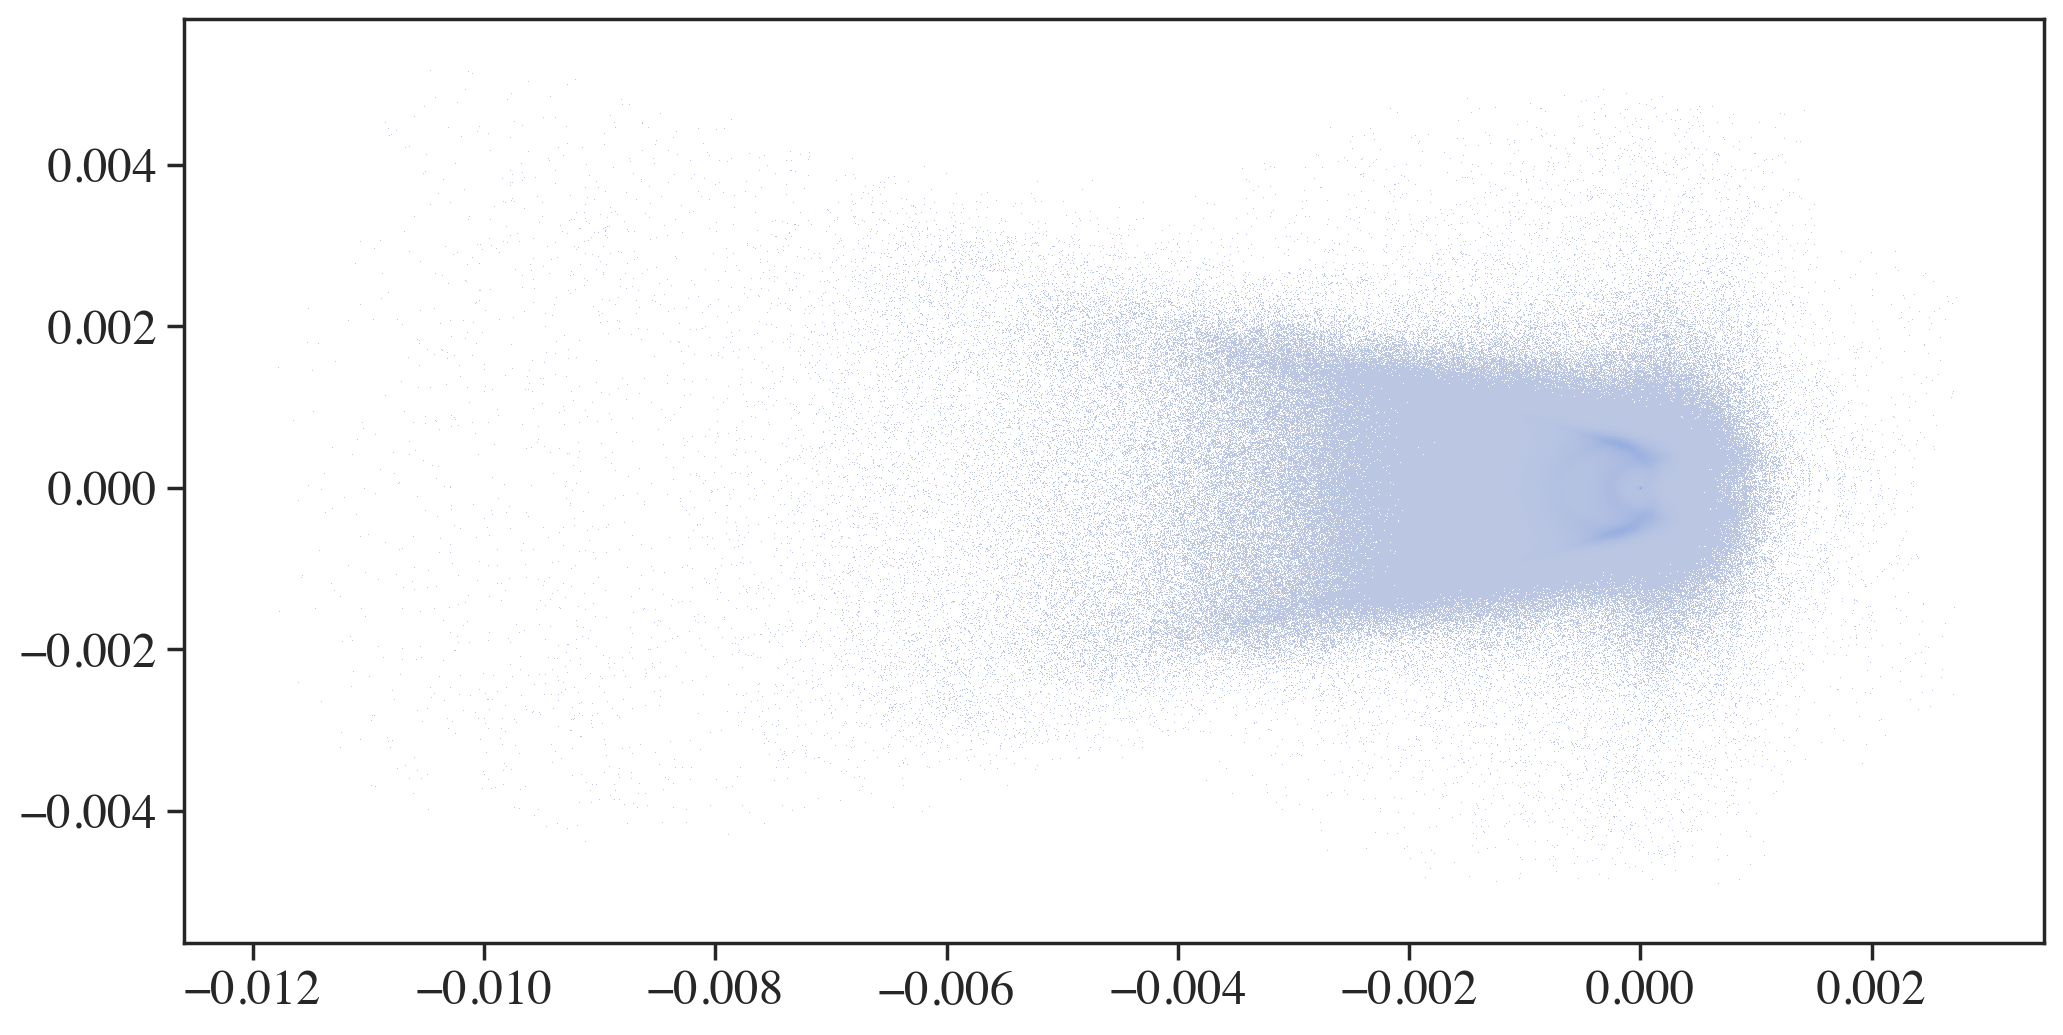

In [31]:
sns.histplot(x=(ts.Z**2*np.exp(-1j*ts.theta)).real.values.flatten(),y=(ts.Z**2*np.exp(-1j*ts.theta)).imag.values.flatten());

(-3.141592653589793, 9.42477796076938)

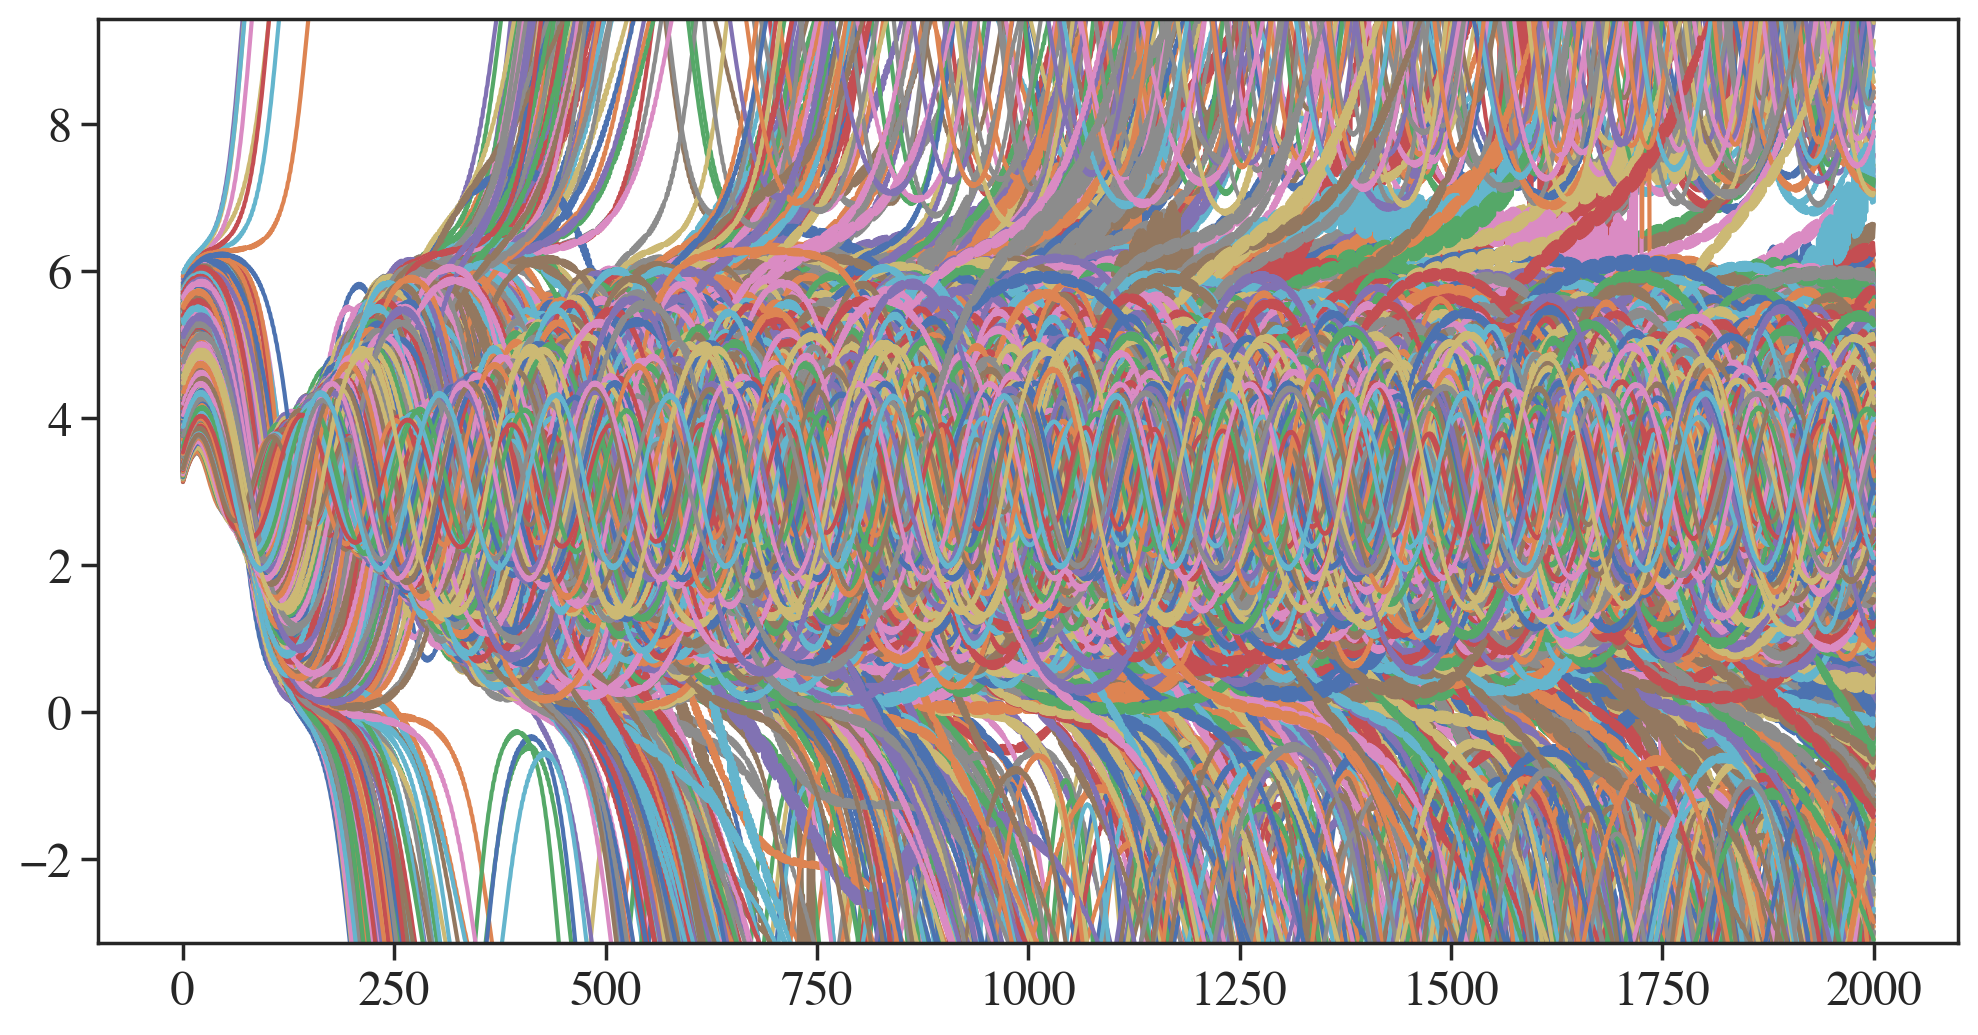

In [25]:
plt.plot(ts.t/365,np.unwrap(ts.trueres,axis=1,period=2*np.pi,).T);
plt.ylim(-np.pi,3*np.pi)

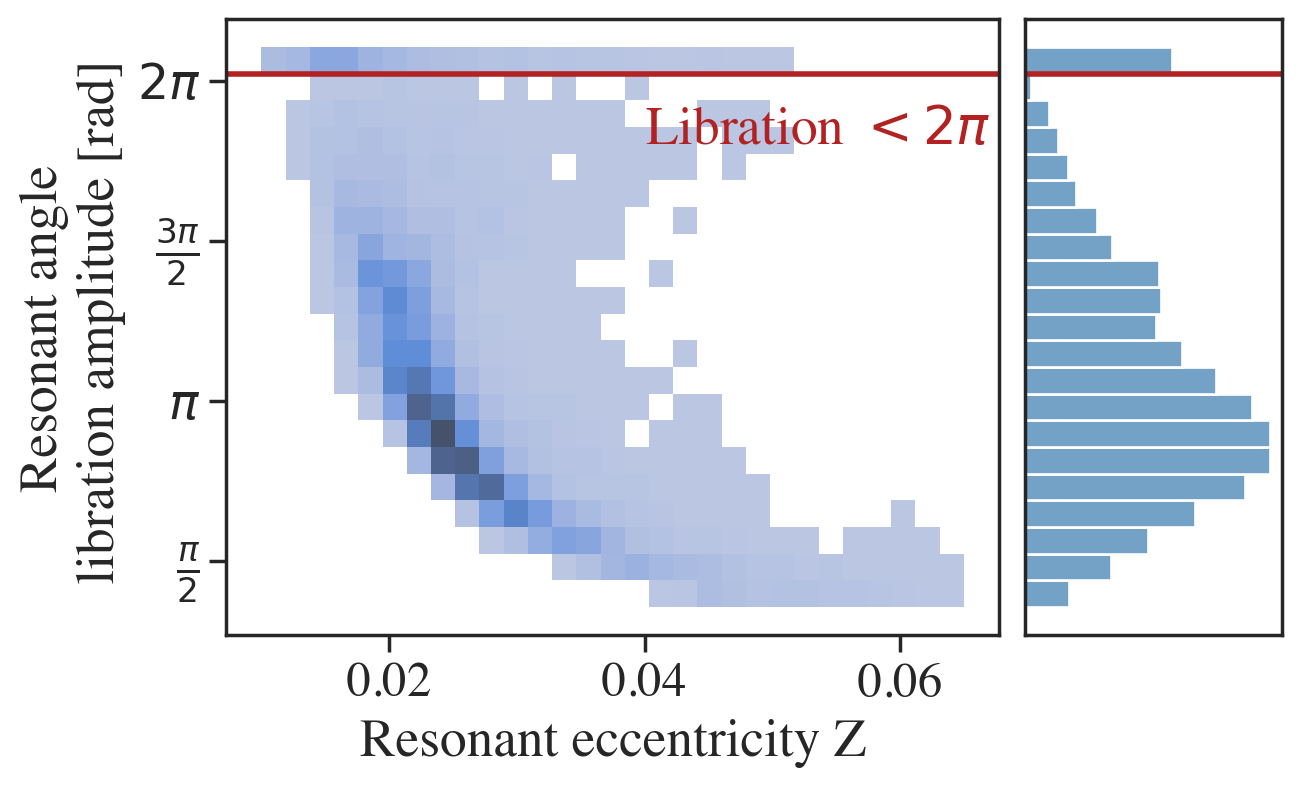

In [ ]:
# 1) Create the figure with two horizontally-connected axes
fig, ax_joint = plt.subplots(1, 2,
                             figsize=(6, 4),
                             gridspec_kw={"width_ratios": [3, 1],
                                          "wspace": 0.05,
                                          "left": 0.08,
                                          "right": 0.96})

# 2) Left panel: 2-D histogram
sns.histplot(x=abs(ts.Z).mean("t"),
             y=np.minimum(6.3,np.unwrap(ts.trueres,axis=1,period=2*np.pi,).max(axis=1)-np.unwrap(ts.trueres,axis=1,period=2*np.pi,).min(axis=1)),
             bins=(np.linspace(0.01,0.065,30),np.arange(np.pi/3,2*np.pi+0.3,np.pi/12)),
             ax=ax_joint[0]
)

# 3) Right panel: 1-D histogram (vertical)
sns.histplot(
    y=np.minimum(6.3,np.unwrap(ts.trueres,axis=1,period=2*np.pi,).max(axis=1)-np.unwrap(ts.trueres,axis=1,period=2*np.pi,).min(axis=1)),
    bins=np.arange(np.pi/3,2*np.pi+0.3,np.pi/12),
    ax=ax_joint[1],
    color="steelblue"
)
ax_joint[0].set_ylabel("Resonant angle\n libration amplitude [rad]")
ax_joint[0].set_xlabel("Resonant eccentricity Z")

ax_joint[0].text(0.04,5.6,r"Libration $< 2\pi$",color="firebrick")


y_vals = np.arange(1.5, 2.1 * np.pi , np.pi / 2)
y_labs = [r"$\frac{\pi}{2}$",r"$\pi$",r"$\frac{3\pi}{2}$",r"$2\pi$"]
ax_joint[0].set_yticks(y_vals)
ax_joint[0].set_yticklabels(y_labs)
ax_joint[1].yaxis.set_visible(False)  # hides y-axis line & ticks
ax_joint[1].xaxis.set_visible(False)  # hides y-axis line & ticks
# 4) Shared y-axis, labels, and 2π line
for ax in ax_joint:
    ax.axhline(2 * np.pi, color="firebrick", lw=2)


# 5) Remove redundant x-axis label on the right panel
ax_joint[1].set_xlabel("")

fig.savefig("Librationvz.pdf",bbox_inches="tight")

In [22]:


def pi_formatter(x, pos):
    if np.isclose(x, 0):
        return "0"
    frac = x / np.pi
    # Show integers nicely
    if np.isclose(frac, np.round(frac)):
        return rf"{int(np.round(frac))}$\pi$"
    return rf"${frac:.1f}\pi$"